## Hospital Billing Event Log

### Data import

In [5]:
import pandas as pd

df = pd.read_csv("Hospital Billing - Event Log_cleaned.csv")

print(df.head())
print(df.columns)
print(df.info())

  Case ID Activity Resource       Complete Timestamp    Variant  \
0       A      NEW     ResA  2012-12-16 19:33:10.000  Variant 3   
1       A      FIN      NaN  2013-12-15 19:00:37.000  Variant 3   
2       A  RELEASE      NaN  2013-12-16 03:53:38.000  Variant 3   
3       A  CODE OK      NaN  2013-12-17 12:56:29.000  Variant 3   
4       A   BILLED     ResB  2013-12-19 03:44:31.000  Variant 3   

   Variant index lifecycle:transition isCancelled diagnosis caseType  ...  \
0              3             complete       False         A        A  ...   
1              3             complete         NaN       NaN      NaN  ...   
2              3             complete         NaN       NaN      NaN  ...   
3              3             complete         NaN       NaN      NaN  ...   
4              3             complete         NaN       NaN      NaN  ...   

   flagA        state closeCode actRed actOrange  flagC msgCount version  \
0  False  In progress       NaN    NaN       NaN    NaN   

In [6]:
print(df.columns)

Index(['Case ID', 'Activity', 'Resource', 'Complete Timestamp', 'Variant',
       'Variant index', 'lifecycle:transition', 'isCancelled', 'diagnosis',
       'caseType', 'speciality', 'blocked', 'isClosed', 'flagD', 'flagB',
       'flagA', 'state', 'closeCode', 'actRed', 'actOrange', 'flagC',
       'msgCount', 'version', 'msgType', 'msgCode'],
      dtype='str')


In [7]:
import pandas as pd

from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter

# CSV laden
df = pd.read_csv("Hospital Billing - Event Log_cleaned.csv")

# Relevante Spalten umbenennen
df = df.rename(columns={
    "Case ID": "case:concept:name",
    "Activity": "concept:name",
    "Complete Timestamp": "time:timestamp",
    "Resource": "org:resource"
})

# Timestamp konvertieren
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

# Für pm4py vorbereiten
df = dataframe_utils.convert_timestamp_columns_in_df(df)

# Chronologisch sortieren
df = df.sort_values(
    by=["case:concept:name", "time:timestamp"]
)

# Event Log erzeugen
log = log_converter.apply(df)

print("Log erfolgreich erstellt")

Log erfolgreich erstellt


In [8]:
print(df.head())

print(df[[
    "case:concept:name",
    "concept:name",
    "org:resource",
    "time:timestamp"
]].isnull().sum())

  case:concept:name concept:name org:resource            time:timestamp  \
0                 A          NEW         ResA 2012-12-16 19:33:10+00:00   
1                 A          FIN          NaN 2013-12-15 19:00:37+00:00   
2                 A      RELEASE          NaN 2013-12-16 03:53:38+00:00   
3                 A      CODE OK          NaN 2013-12-17 12:56:29+00:00   
4                 A       BILLED         ResB 2013-12-19 03:44:31+00:00   

     Variant  Variant index lifecycle:transition isCancelled diagnosis  \
0  Variant 3              3             complete       False         A   
1  Variant 3              3             complete         NaN       NaN   
2  Variant 3              3             complete         NaN       NaN   
3  Variant 3              3             complete         NaN       NaN   
4  Variant 3              3             complete         NaN       NaN   

  caseType  ...  flagA        state closeCode actRed actOrange  flagC  \
0        A  ...  False  In prog

### First insights

In [9]:
# Wie viele Resourcen gibt es?
print(df["org:resource"].nunique())

1150


In [10]:
# Welche Ressourcen bearbeiten die meisten Events?
resource_counts = (
    df["org:resource"]
    .value_counts()
)

print(resource_counts.head(20))

org:resource
ResA     72641
ResB     56337
ResIA     4597
ResHG     4475
ResU      3467
ResDA     2503
ResGA     2218
ResJA     2175
ResNC     2136
ResYC     1683
ResK      1467
ResQA     1435
ResDB     1275
ResXG     1192
ResNA     1183
ResSB     1068
ResP      1025
ResWB      947
ResI       823
ResG       818
Name: count, dtype: int64


Sehr schiefe Verteilung

In [11]:
# Wie viele Ressourcen arbeiten an einem Case?
resources_per_case = (
    df.groupby("case:concept:name")["org:resource"]
    .nunique()
)

print(resources_per_case.describe())

count    77627.000000
mean         2.846896
std          0.936588
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max         11.000000
Name: org:resource, dtype: float64


Meistens werden Fälle von 2-3 Mitarbeitern bearbeitet. Es gibt auch aber auch seltene Fälle, die von 11 Resourcen bearbeitet wurden.

In [12]:
# Case Duration berechnen
case_duration = (
    df.groupby("case:concept:name")["time:timestamp"]
    .agg(["min", "max"])
)

case_duration["duration_hours"] = (
    case_duration["max"] - case_duration["min"]
).dt.total_seconds() / 3600

# Print: zentrale Deskriptivstatistiken
print("Case Duration (hours) Summary:")
print(case_duration["duration_hours"].describe())

print("\nMedian duration (hours):", case_duration["duration_hours"].median())
print("Max duration (hours):", case_duration["duration_hours"].max())
print("Min duration (hours):", case_duration["duration_hours"].min())

Case Duration (hours) Summary:
count    77627.000000
mean      3937.653015
std       3039.959316
min          0.000278
25%       2243.515417
50%       2924.965556
75%       5235.768750
max      24850.108889
Name: duration_hours, dtype: float64

Median duration (hours): 2924.9655555555555
Max duration (hours): 24850.108888888888
Min duration (hours): 0.0002777777777777778


Der Median der Duration beträgt 48,75 Tage.    
Maximum: 1035 Tage

In [13]:
# Zusammenhang analysieren
analysis_df = pd.DataFrame({
    "num_resources": resources_per_case,
    "duration_hours": case_duration["duration_hours"]
})

print(analysis_df.corr())

                num_resources  duration_hours
num_resources        1.000000       -0.035312
duration_hours      -0.035312        1.000000


Moderate positive Korrelation  
Interpretation: Mehr Ressourcen im Case → längere Durchlaufzeit   
Aber: Korrelation ist zu schwach, um zu sagen, dass jede Übergabe proportional Zeit kostet. Es spricht eher für einen komplexeren Fall  

Weitere mögliche Störfaktoren in der Korrelation: 
* Case-Komplexität (schwere Fälle brauchen mehr Ressourcen)
* Priorisierung (wichtige Fälle gehen durch mehr Stationen)
* Rework / Schleifen
* unterschiedliche Ressourcentypen

### Spezialisierung von Ressourcen (wie breit arbeiten Mitarbeiter?)

In [14]:
# Spezialisierung von Mitarbeitern
resource_activity_count = df.groupby("org:resource")["concept:name"].nunique()

print("Spezialisierung pro Resource (Anzahl unterschiedlicher Activities):")
print(resource_activity_count.describe())

print("\nTop 10 generalistische Ressourcen:")
print(resource_activity_count.sort_values(ascending=False).head(10))

print("\nTop 10 spezialisierte Ressourcen:")
print(resource_activity_count.sort_values().head(10))

Spezialisierung pro Resource (Anzahl unterschiedlicher Activities):
count    1150.000000
mean        2.160000
std         1.494568
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: concept:name, dtype: float64

Top 10 generalistische Ressourcen:
org:resource
ResGA    15
ResYC    15
ResDB    13
ResWB    13
ResSB    13
ResBA    12
ResIA    12
ResNC    11
ResXD    11
ResA     10
Name: concept:name, dtype: int64

Top 10 spezialisierte Ressourcen:
org:resource
ResMW     1
ResNJA    1
ResNKA    1
ResNLA    1
ResNM     1
ResNMA    1
ResNNA    1
ResNO     1
ResNJ     1
ResNOA    1
Name: concept:name, dtype: int64


Interpretation

* hohe Werte → Resource arbeitet an vielen unterschiedlichen Activities
    → eher Generalist, flexibel einsetzbar
* niedrige Werte → Resource macht wenige Activity-Typen
    → Spezialisierung, klare Rollenverteilung

👉 Typisches Muster:

* Organisationen haben oft eine Mischung aus beiden
* sehr hohe Spezialisierung kann auf starre Prozesse hinweisen
* sehr hohe Generalisierung kann auf flexible, aber evtl. unklare Zuständigkeiten hindeuten

### Welche Activities sind organisatorisch komplex?
(= viele unterschiedliche Mitarbeiter bearbeiten denselben Schritt)

In [15]:
activity_resource_count = df.groupby("concept:name")["org:resource"].nunique()

print("Resource-Varianz pro Activity:")
print(activity_resource_count.describe())

print("\nKomplexeste Activities (viele verschiedene Ressourcen):")
print(activity_resource_count.sort_values(ascending=False).head(10))

print("\nStabilste Activities (wenige Ressourcen):")
print(activity_resource_count.sort_values().head(10))

Resource-Varianz pro Activity:
count      18.000000
mean      138.000000
std       282.737251
min         0.000000
25%         8.250000
50%        13.000000
75%        52.250000
max      1012.000000
Name: org:resource, dtype: float64

Komplexeste Activities (viele verschiedene Ressourcen):
concept:name
NEW             1012
CHANGE DIAGN     686
DELETE           408
REOPEN           187
FIN               63
STORNO            20
REJECT            15
RELEASE           15
BILLED            14
CODE OK           12
Name: org:resource, dtype: int64

Stabilste Activities (wenige Ressourcen):
concept:name
ZDBC_BEHAN     0
CODE ERROR     3
CHANGE END     5
MANUAL         5
EMPTY          8
JOIN-PAT       9
SET STATUS    11
CODE NOK      11
CODE OK       12
BILLED        14
Name: org:resource, dtype: int64


Interpretation

* hohe Werte → Activity wird von vielen verschiedenen Personen bearbeitet
    → geringe Standardisierung, hohe Koordinationslast
* niedrige Werte → klare Zuständigkeit
    → standardisierte, stabile Prozessschritte

👉 Wichtig für deine Story:

* Das ist ein direkter Indikator für Prozessklarheit vs. organisatorische Fragmentierung

### Bottlenecks nach Resource finden

In [16]:
resource_duration = df.merge(
    case_duration["duration_hours"],
    left_on="case:concept:name",
    right_index=True
).groupby("org:resource")["duration_hours"].mean()

print("Top 10 langsamste Ressourcen (Ø Case Duration):")
print(resource_duration.sort_values(ascending=False).head(10))

print("\nTop 10 schnellste Ressourcen:")
print(resource_duration.sort_values().head(10))

Top 10 langsamste Ressourcen (Ø Case Duration):
org:resource
ResWV     13651.210278
ResIEA    11757.627500
ResMN     11545.420833
ResZAA    10958.553889
ResZZ     10116.306667
ResBZ     10037.595444
ResIIA     9850.438889
ResCH      9744.690039
ResLGA     9621.905000
ResQFA     9513.644583
Name: duration_hours, dtype: float64

Top 10 schnellste Ressourcen:
org:resource
ResYQA    0.008611
ResZQA    0.010278
ResLBA    0.020556
ResXBA    0.045833
ResET     0.232778
ResFRA    0.238611
ResPQA    0.454444
ResYG     0.565833
ResCGA    0.571111
ResNNA    0.961389
Name: duration_hours, dtype: float64


### NEU: Case Gruppierung in 1-2 vs. >=3 Resources


In [17]:
resources_per_case = df.groupby("case:concept:name")["org:resource"].nunique()

case_duration = (
    df.groupby("case:concept:name")["time:timestamp"]
    .agg(["min", "max"])
)

case_duration["duration_hours"] = (
    case_duration["max"] - case_duration["min"]
).dt.total_seconds() / 3600

analysis_df = pd.DataFrame({
    "num_resources": resources_per_case,
    "duration_hours": case_duration["duration_hours"]
})

# Neue sinnvolle Gruppen
analysis_df["fragmentation_group"] = analysis_df["num_resources"].apply(
    lambda x: "low (1-2)" if x <= 2 else "high (3+)"
)

print(analysis_df["fragmentation_group"].value_counts())

fragmentation_group
high (3+)    49678
low (1-2)    27949
Name: count, dtype: int64


In [18]:
# Neue Performance Analyse
print("Duration by fragmentation group:")

group_stats = analysis_df.groupby("fragmentation_group")["duration_hours"].describe()

print(group_stats)

print("\nMean comparison:")
print(analysis_df.groupby("fragmentation_group")["duration_hours"].mean())

Duration by fragmentation group:
                       count         mean          std       min          25%  \
fragmentation_group                                                             
high (3+)            49678.0  3642.857350  2553.352018  0.191111  2389.173750   
low (1-2)            27949.0  4461.638096  3694.656582  0.000278   854.403611   

                             50%          75%           max  
fragmentation_group                                          
high (3+)            2814.939583  4255.710625  24850.108889  
low (1-2)            3148.275833  8905.111111  23704.673611  

Mean comparison:
fragmentation_group
high (3+)    3642.857350
low (1-2)    4461.638096
Name: duration_hours, dtype: float64


In [19]:
# Neu: Vergleich der Gruppen (keine Korrelation mehr)
low = analysis_df[analysis_df["fragmentation_group"] == "low (1-2)"]
high = analysis_df[analysis_df["fragmentation_group"] == "high (3+)"]

print("Mean duration - low fragmentation:", low["duration_hours"].mean())
print("Mean duration - high fragmentation:", high["duration_hours"].mean())

print("\nDifference (high - low):")
print(high["duration_hours"].mean() - low["duration_hours"].mean())

Mean duration - low fragmentation: 4461.63809622487
Mean duration - high fragmentation: 3642.857349698727

Difference (high - low):
-818.7807465261435


In [20]:
# Welche Resourcen sind stark mit high fregmantation cases verbunden?
df_enriched = df.merge(
    analysis_df["fragmentation_group"],
    left_on="case:concept:name",
    right_index=True
)

resource_frag = pd.crosstab(
    df_enriched["org:resource"],
    df_enriched["fragmentation_group"]
)

resource_frag["high_ratio"] = (
    resource_frag["high (3+)"] /
    (resource_frag["low (1-2)"] + resource_frag["high (3+)"])
)

print("Top resources most associated with high-fragmentation cases:")
print(resource_frag.sort_values("high_ratio", ascending=False).head(15))

Top resources most associated with high-fragmentation cases:
fragmentation_group  high (3+)  low (1-2)  high_ratio
org:resource                                         
ResZZ                        1          0         1.0
ResJIA                       1          0         1.0
ResKAA                       3          0         1.0
ResJY                        2          0         1.0
ResJR                        1          0         1.0
ResJPA                       1          0         1.0
ResJP                        2          0         1.0
ResJOA                       1          0         1.0
ResUHA                      32          0         1.0
ResJNA                      34          0         1.0
ResJN                       13          0         1.0
ResJLA                       1          0         1.0
ResJKA                       1          0         1.0
ResUIA                       2          0         1.0
ResJJA                      16          0         1.0


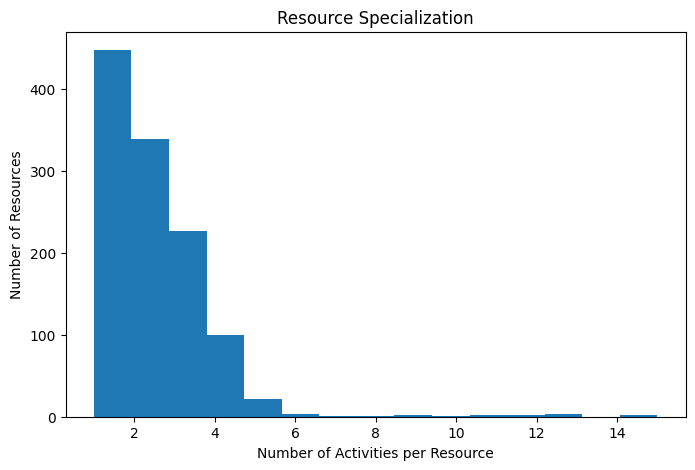

In [21]:
# Slide visualization histogram
import matplotlib.pyplot as plt

# Anzahl unterschiedlicher Activities pro Resource
activities_per_resource = (
    df.groupby("org:resource")["concept:name"]
    .nunique()
)

# Histogramm
plt.figure(figsize=(8, 5))

plt.hist(activities_per_resource, bins=15)

plt.xlabel("Number of Activities per Resource")
plt.ylabel("Number of Resources")
plt.title("Resource Specialization")

plt.show()

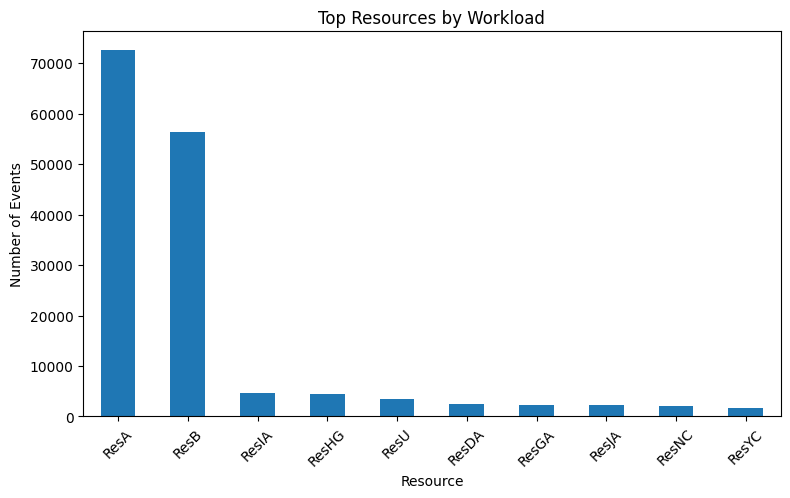

In [22]:
# Slide visualization barplot
import matplotlib.pyplot as plt

# Top 10 Ressourcen nach Anzahl Events
top_resources = (
    df["org:resource"]
    .value_counts()
    .head(10)
)

# Barplot
plt.figure(figsize=(9, 5))

top_resources.plot(kind="bar")

plt.xlabel("Resource")
plt.ylabel("Number of Events")
plt.title("Top Resources by Workload")

plt.xticks(rotation=45)

plt.show()

### Ressourcen pro Case

In [23]:
# Case Fragmentation
# Ressourcen pro Case
resources_per_case = df.groupby("case:concept:name")["org:resource"].nunique()

# Case Duration berechnen
case_duration = (
    df.groupby("case:concept:name")["time:timestamp"]
    .agg(["min", "max"])
)

case_duration["duration_hours"] = (
    case_duration["max"] - case_duration["min"]
).dt.total_seconds() / 3600

# Zusammenführen
analysis_df = pd.DataFrame({
    "num_resources": resources_per_case,
    "duration_hours": case_duration["duration_hours"]
})

# Neue feinere Gruppen
analysis_df["frag_group"] = analysis_df["num_resources"].apply(
    lambda x: "1–2" if x <= 2
    else "3–4" if x <= 4
    else "5+"
)

print(analysis_df["frag_group"].value_counts())

frag_group
3–4    46424
1–2    27949
5+      3254
Name: count, dtype: int64


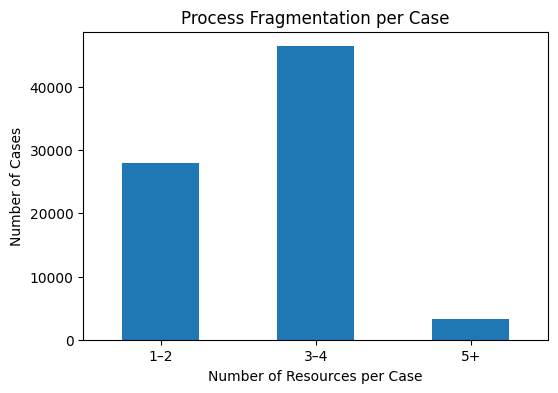

In [24]:
import matplotlib.pyplot as plt

group_counts = analysis_df["frag_group"].value_counts().sort_index()

plt.figure(figsize=(6,4))

group_counts.plot(kind="bar")

plt.title("Process Fragmentation per Case")
plt.xlabel("Number of Resources per Case")
plt.ylabel("Number of Cases")

plt.xticks(rotation=0)

plt.show()

In [25]:
resources_per_case = df.groupby("case:concept:name")["org:resource"].nunique()

case_duration = (
    df.groupby("case:concept:name")["time:timestamp"]
    .agg(["min", "max"])
)

case_duration["duration_hours"] = (
    case_duration["max"] - case_duration["min"]
).dt.total_seconds() / 3600

analysis_df = pd.DataFrame({
    "num_resources": resources_per_case,
    "duration_hours": case_duration["duration_hours"]
})

In [26]:
analysis_df["frag_group"] = analysis_df["num_resources"].apply(
    lambda x: "1–2" if x <= 2 else "3" if x == 3 else "4+"
)

print(analysis_df["frag_group"].value_counts())

frag_group
3      33972
1–2    27949
4+     15706
Name: count, dtype: int64


In [27]:
avg_duration = analysis_df.groupby("frag_group")["duration_hours"].mean()

print("Average Case Duration per Fragmentation Group:")
print(avg_duration)

Average Case Duration per Fragmentation Group:
frag_group
1–2    4461.638096
3      3557.857938
4+     3826.710656
Name: duration_hours, dtype: float64


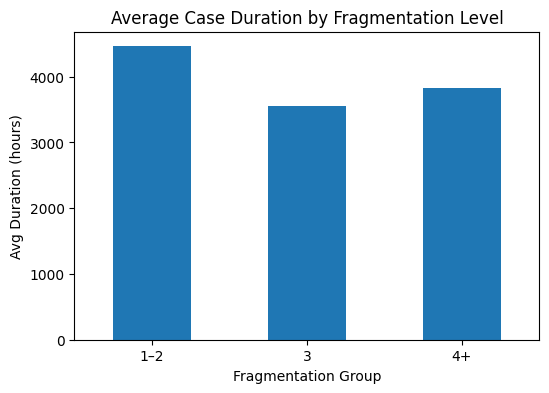

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

avg_duration.sort_index().plot(kind="bar")

plt.title("Average Case Duration by Fragmentation Level")
plt.xlabel("Fragmentation Group")
plt.ylabel("Avg Duration (hours)")

plt.xticks(rotation=0)

plt.show()

In [29]:
resources_per_case = df.groupby("case:concept:name")["org:resource"].nunique()

case_duration = (
    df.groupby("case:concept:name")["time:timestamp"]
    .agg(["min", "max"])
)

case_duration["duration_hours"] = (
    case_duration["max"] - case_duration["min"]
).dt.total_seconds() / 3600

analysis_df = pd.DataFrame({
    "num_resources": resources_per_case,
    "duration_hours": case_duration["duration_hours"]
})

avg_duration = analysis_df.groupby("num_resources")["duration_hours"].mean()

# richtige Reihenfolge bauen
order = list(range(1, 12)) 

avg_duration = avg_duration.reindex(order)

print(avg_duration)

num_resources
1      3113.015692
2      4674.111056
3      3557.857938
4      3542.021315
5      4600.490345
6      5656.269712
7      7281.014010
8      7639.308356
9     11075.164278
10     7536.060463
11     8931.541944
Name: duration_hours, dtype: float64


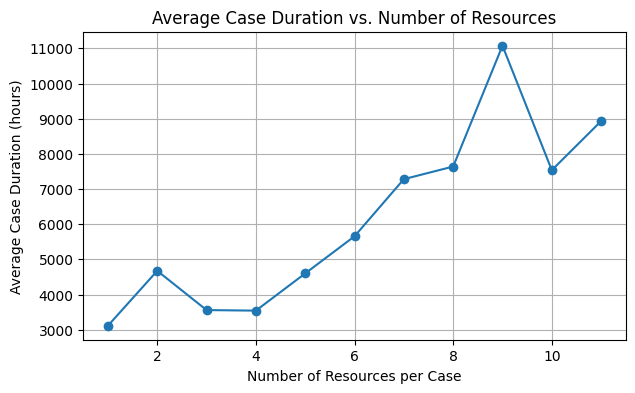

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

avg_duration.plot(marker="o")

plt.title("Average Case Duration vs. Number of Resources")
plt.xlabel("Number of Resources per Case")
plt.ylabel("Average Case Duration (hours)")

plt.grid(True)

plt.show()

In [31]:
# How many resources work on a case
resources_per_case = df.groupby("case:concept:name")["org:resource"].nunique()

print(resources_per_case.describe())
print("\nValue counts (raw):")
print(resources_per_case.value_counts().sort_index())

count    77627.000000
mean         2.846896
std          0.936588
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max         11.000000
Name: org:resource, dtype: float64

Value counts (raw):
org:resource
1      3804
2     24145
3     33972
4     12452
5      2550
6       548
7       122
8        25
9         5
10        3
11        1
Name: count, dtype: int64


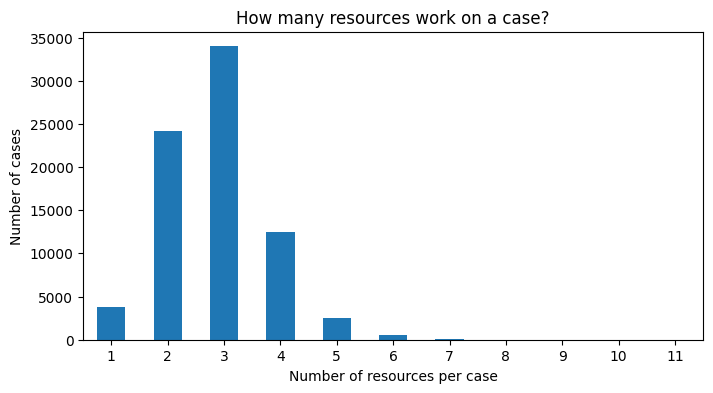

In [32]:
import matplotlib.pyplot as plt

counts = resources_per_case.value_counts().sort_index()

plt.figure(figsize=(8,4))

counts.plot(kind="bar")

plt.title("How many resources work on a case?")
plt.xlabel("Number of resources per case")
plt.ylabel("Number of cases")

plt.xticks(rotation=0)

plt.show()

## Nach der Zwischenpräsentation

In [33]:
# In wie vielen Cases sind ResA und ResB beteiligt?
# Filter auf relevante Ressourcen
subset = df[df["org:resource"].isin(["ResA", "ResB"])]

# Anzahl Cases pro Ressource
cases_per_resource = (
    subset.groupby("org:resource")["case:concept:name"]
    .nunique()
)

print(cases_per_resource)

org:resource
ResA    69484
ResB    54826
Name: case:concept:name, dtype: int64


ResA und ResB sind in fast jedem Case involviert

Erklärungen:
* Vielleicht Automation
* Backoffice Rollen für den Billing Prozess

In [34]:
# Varianz in Aktivitätendauer
df[df["org:resource"].isin(["ResA","ResB"])].groupby("concept:name")["time:timestamp"].nunique()

concept:name
BILLED      56308
CODE NOK      152
CODE OK        55
DELETE         11
FIN         46563
JOIN-PAT       61
MANUAL         21
NEW         22453
REJECT         48
RELEASE      2768
REOPEN          2
STORNO        272
Name: time:timestamp, dtype: int64

### Resource Activity Heatmap

In [35]:
activity_matrix = pd.crosstab(
    df["org:resource"],
    df["concept:name"]
)

print(activity_matrix.head())

concept:name  BILLED  CHANGE DIAGN  CHANGE END  CODE ERROR  CODE NOK  CODE OK  \
org:resource                                                                    
ResA             221             0           0           0       152       55   
ResAA              0             4           0           0         0        0   
ResAAA             0             1           0           0         0        0   
ResAB              0            83           0           0         0        0   
ResABA             0            13           0           0         0        0   

concept:name  DELETE  EMPTY    FIN  JOIN-PAT  MANUAL    NEW  REJECT  RELEASE  \
org:resource                                                                   
ResA               4      0  46648         0      21  22466      30     2783   
ResAA              2      0      0         0       0     33       0        0   
ResAAA             0      0      0         0       0     11       0        0   
ResAB              2      0     

In [36]:
# Matrix filtern
top_resources = (
    df["org:resource"]
    .value_counts()
    .head(15)
    .index
)

filtered_matrix = activity_matrix.loc[top_resources]

print(filtered_matrix)

concept:name  BILLED  CHANGE DIAGN  CHANGE END  CODE ERROR  CODE NOK  CODE OK  \
org:resource                                                                    
ResA             221             0           0           0       152       55   
ResB           56233             0           0           0         0        0   
ResIA            258             0           0           0       196      835   
ResHG           4212             0           0           0         0        0   
ResU            3071             0           0           0         0        1   
ResDA              0           171           0           0         0        0   
ResGA             11             7           4           1        18       52   
ResJA              0             0           0           0         0        0   
ResNC             38             0           0           0         4       60   
ResYC             10             8           3           1        13       31   
ResK               0        

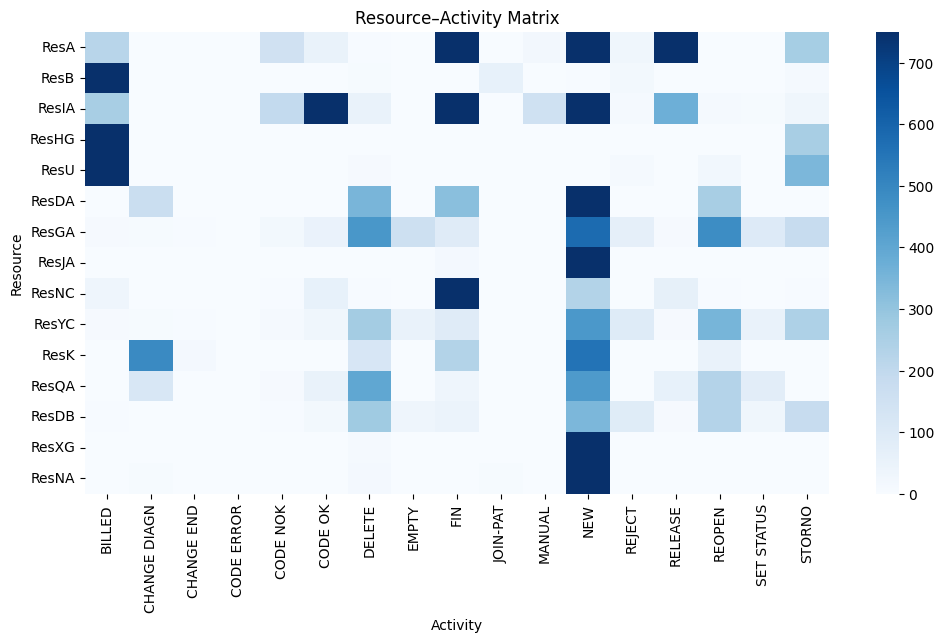

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    filtered_matrix,
    cmap="Blues",
    vmax=750
)

plt.title("Resource–Activity Matrix")
plt.xlabel("Activity")
plt.ylabel("Resource")

plt.show()

### Scatterplot

In [38]:
import pandas as pd

# Sortieren (wichtig für korrekte Handover-Berechnung)
df = df.sort_values(["case:concept:name", "time:timestamp"])

# Next resource pro Event
df["next_resource"] = df.groupby("case:concept:name")["org:resource"].shift(-1)

# Handover definieren (nur echte Übergaben)
handover_df = df.dropna(subset=["next_resource"])
handover_df = handover_df[
    handover_df["org:resource"] != handover_df["next_resource"]
]

# Anzahl Handovers pro Case
handover_per_case = (
    handover_df.groupby("case:concept:name")
    .size()
    .reset_index(name="num_handovers")
)

# Case Duration berechnen (falls noch nicht vorhanden)
case_duration = (
    df.groupby("case:concept:name")["time:timestamp"]
    .agg(lambda x: (x.max() - x.min()).total_seconds() / 3600)
    .reset_index(name="duration")
)

# Merging
case_df = case_duration.merge(handover_per_case, on="case:concept:name", how="left")

# Cases ohne Handovers auf 0 setzen
case_df["num_handovers"] = case_df["num_handovers"].fillna(0).astype(int)

In [39]:
# Durchschnittliche Dauer pro Handover-Anzahl
handover_duration = (
    case_df.groupby("num_handovers")["duration"]
    .mean()
    .reset_index()
)

handover_duration.rename(
    columns={
        "num_handovers": "handover_bucket",
        "duration": "avg_duration"
    },
    inplace=True
)

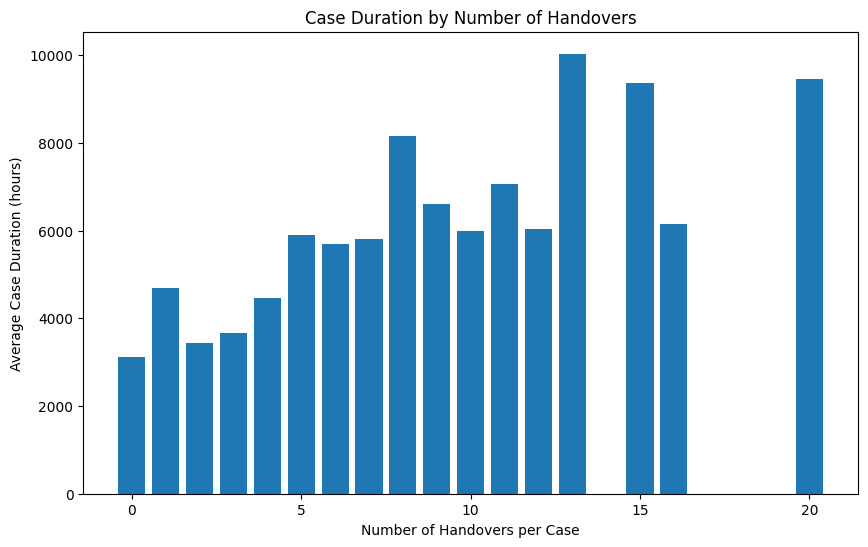

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(
    handover_duration["handover_bucket"],
    handover_duration["avg_duration"]
)

plt.xlabel("Number of Handovers per Case")
plt.ylabel("Average Case Duration (hours)")
plt.title("Case Duration by Number of Handovers")
plt.show()

In [41]:
# Erweiterte Aggregation: Durchschnitt + Anzahl Cases + Std (optional aber sehr hilfreich)
handover_summary = (
    case_df.groupby("num_handovers")
    .agg(
        avg_duration=("duration", "mean"),
        case_count=("duration", "count"),
        std_duration=("duration", "std")
    )
    .reset_index()
    .rename(columns={"num_handovers": "handover_bucket"})
)

# Sortieren für bessere Lesbarkeit
handover_summary = handover_summary.sort_values("handover_bucket")

handover_summary

,handover_bucket,avg_duration,case_count,std_duration
0,0,3114.902705,3800,3308.845510
1,1,4678.454659,23970,3712.595292
2,2,3431.990275,32424,2257.968524
3,3,3667.336404,12648,2563.344801
4,4,4464.783122,2986,3335.254279
5,5,5889.951196,1044,4209.374716
6,6,5682.274457,430,3924.897088
7,7,5800.718788,190,3940.346632
8,8,8161.416712,67,4495.034609
9,9,6604.353530,31,4028.591325


## Handover Matrix

In [ ]:
in_degree = dict(G.in_degree(weight='weight'))
out_degree = dict(G.out_degree(weight='weight'))

centrality_df = pd.DataFrame({
    'in_degree': in_degree,
    'out_degree': out_degree
}).fillna(0)

centrality_df.sort_values('out_degree', ascending=False).head(10)

,in_degree,out_degree
UNASSIGNED,279905,202278
ResA,50175,72641
ResB,56333,56337
ResIA,3804,4597
ResHG,4475,4475
ResU,3466,3467
ResDA,1099,2503
ResGA,1639,2218
ResJA,16,2175
ResNC,1902,2136


### Heatmap neu

In [ ]:
df = df.sort_values(["case:concept:name", "time:timestamp"])

df["next_resource"] = df.groupby("case:concept:name")["org:resource"].shift(-1)

print("NaN next_resource:", df["next_resource"].isna().sum())
print("Total rows:", len(df))
print("Unique cases:", df["case:concept:name"].nunique())

NaN next_resource: 279905
Total rows: 428986
Unique cases: 77627


In [ ]:
import pandas as pd

# ----------------------------
# 1. Sort events chronologically within each case
# ----------------------------
df = df.sort_values(["case:concept:name", "time:timestamp"])

# ----------------------------
# 2. Create next resource per case (event sequence)
# ----------------------------
df["next_resource"] = df.groupby("case:concept:name")["org:resource"].shift(-1)

# ----------------------------
# 3. Remove last event per case (no successor)
# ----------------------------
handover_df = df.dropna(subset=["next_resource"])

# ----------------------------
# 4. Remove self-loops (A → A)
# ----------------------------
handover_df = handover_df[
    handover_df["org:resource"] != handover_df["next_resource"]
]

# ----------------------------
# 5. Count handovers
# ----------------------------
handover_counts = (
    handover_df
    .groupby(["org:resource", "next_resource"])
    .size()
    .reset_index(name="count")
)

# ----------------------------
# 6. Build full resource set (IMPORTANT FIX)
# ----------------------------
all_resources = pd.Index(df["org:resource"].dropna().unique())

# ----------------------------
# 7. Pivot to matrix
# ----------------------------
handover_matrix = handover_counts.pivot(
    index="org:resource",
    columns="next_resource",
    values="count"
)

# ----------------------------
# 8. Force full matrix (no missing rows/cols)
# ----------------------------
handover_matrix = handover_matrix.reindex(
    index=all_resources,
    columns=all_resources,
    fill_value=0
)

# ----------------------------
# 9. Final cleanup
# ----------------------------
handover_matrix = handover_matrix.fillna(0)

# ----------------------------
# 10. Optional: inspect
# ----------------------------
print(handover_matrix.shape)

(1150, 1150)


In [ ]:
handover_norm = handover_matrix.div(
    handover_matrix.sum(axis=1),
    axis=0
).fillna(0)

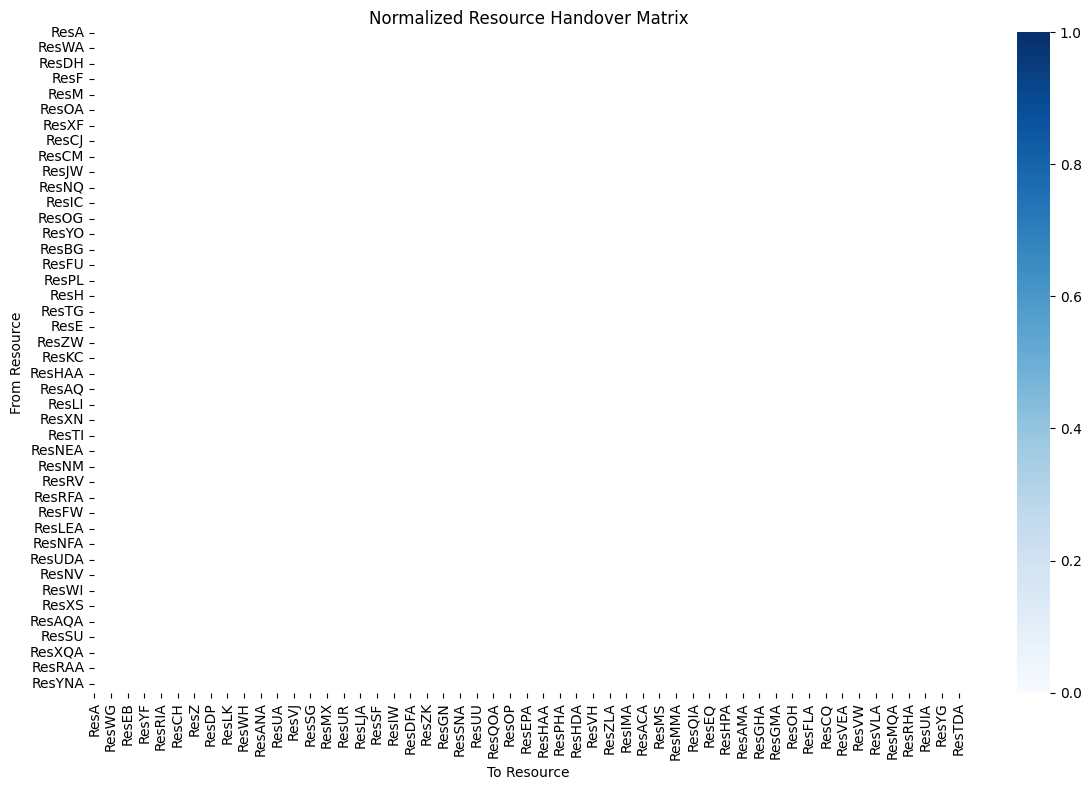

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    handover_norm,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Normalized Resource Handover Matrix")
plt.xlabel("To Resource")
plt.ylabel("From Resource")
plt.tight_layout()
plt.show()

In [ ]:
top_handover = (
    handover_counts
    .sort_values("count", ascending=False)
    .head(25)
)

top_handover

,org:resource,next_resource,count
2828,ResJA,ResNC,1616
2567,ResIA,ResA,1191
1180,ResDA,ResA,1112
648,ResB,ResIA,495
2066,ResGA,ResA,475
3103,ResK,ResA,433
4539,ResP,ResA,429
2569,ResIA,ResB,369
1147,ResCX,ResA,351
16,ResA,ResB,333


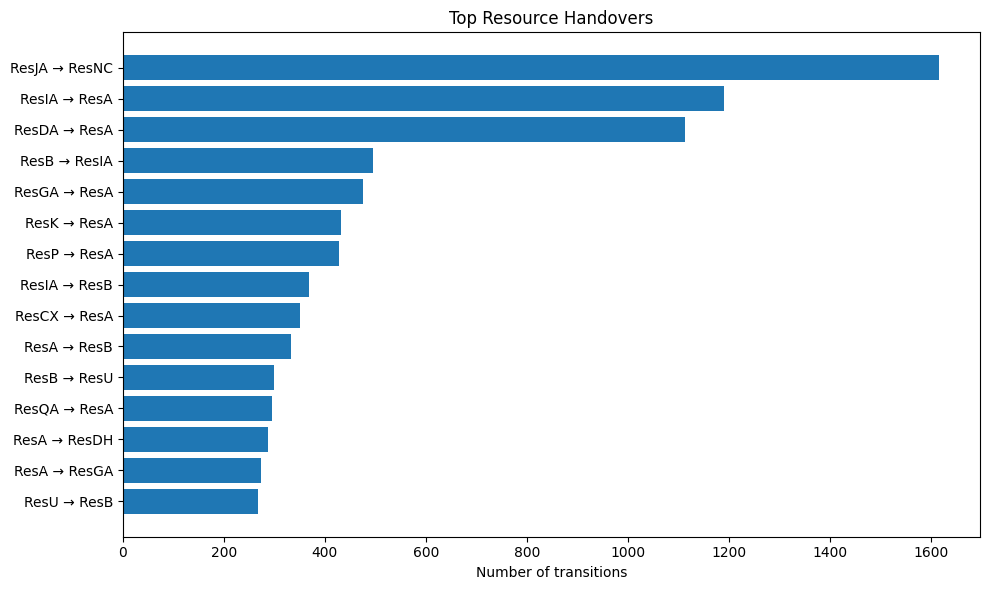

In [ ]:
import matplotlib.pyplot as plt

top10 = top_handover.head(25)

labels = top10["org:resource"] + " → " + top10["next_resource"]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], top10["count"][::-1])

plt.title("Top Resource Handovers")
plt.xlabel("Number of transitions")
plt.tight_layout()
plt.show()

In [ ]:
# Handover Intensity per Resource
out_degree = handover_counts.groupby("org:resource")["count"].sum()
in_degree = handover_counts.groupby("next_resource")["count"].sum()

degree_df = pd.DataFrame({
    "outgoing": out_degree,
    "incoming": in_degree
}).fillna(0)

degree_df["total"] = degree_df["outgoing"] + degree_df["incoming"]

degree_df.sort_values("total", ascending=False).head(10)

,outgoing,incoming,total
ResA,4381.0,22099.0,26480.0
ResIA,1828.0,2296.0,4124.0
ResB,2475.0,1584.0,4059.0
ResDA,1659.0,758.0,2417.0
ResJA,2087.0,14.0,2101.0
ResNC,304.0,1792.0,2096.0
ResK,811.0,776.0,1587.0
ResGA,647.0,626.0,1273.0
ResP,484.0,691.0,1175.0
ResNA,1132.0,22.0,1154.0


### Säulendiagramm

In [ ]:
import pandas as pd

# Sortieren für Handover-Logik
df_sorted = df.sort_values(["case:concept:name", "time:timestamp"])

# Next resource
df_sorted["next_resource"] = df_sorted.groupby("case:concept:name")["org:resource"].shift(-1)

# gültige Handover (echte Wechsel)
handover_df = df_sorted.dropna(subset=["next_resource"])
handover_df = handover_df[handover_df["org:resource"] != handover_df["next_resource"]]

In [ ]:
# Anzahl Ressourcen pro Case
case_resources = df.groupby("case:concept:name")["org:resource"].nunique()

# Anzahl Handovers pro Case
case_handovers = handover_df.groupby("case:concept:name").size()

# kombinieren
case_df = pd.DataFrame({
    "num_resources": case_resources,
    "handovers": case_handovers
}).fillna(0)

In [ ]:
agg = case_df.groupby("num_resources").agg(
    case_count=("handovers", "count"),
    total_handovers=("handovers", "sum")
).reset_index()

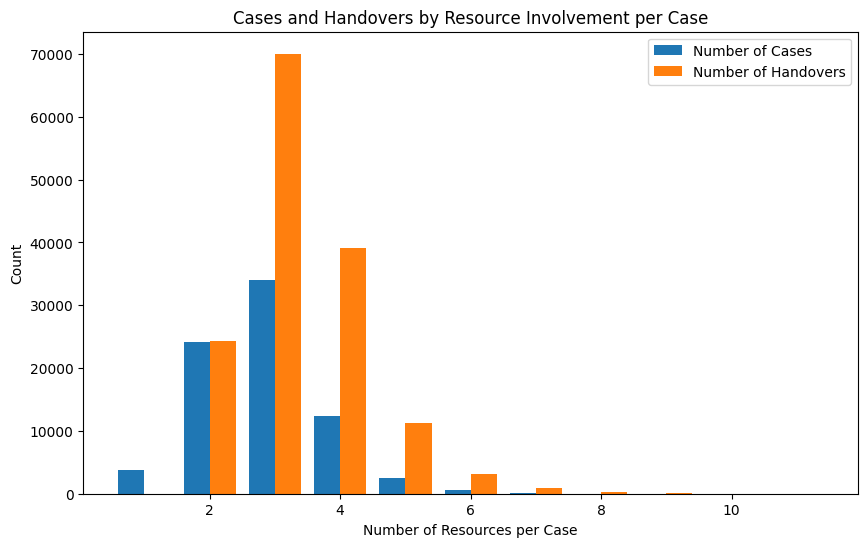

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = agg["num_resources"]

plt.figure(figsize=(10,6))

# Cases
plt.bar(x - 0.2, agg["case_count"], width=0.4, label="Number of Cases")

# Handovers (absolute Summe)
plt.bar(x + 0.2, agg["total_handovers"], width=0.4, label="Number of Handovers")

plt.xlabel("Number of Resources per Case")
plt.ylabel("Count")
plt.title("Cases and Handovers by Resource Involvement per Case")
plt.legend()

plt.show()

In [ ]:
print(agg)

    num_resources  case_count  total_handovers
0               1        3804              4.0
1               2       24145          24356.0
2               3       33972          70056.0
3               4       12452          39051.0
4               5        2550          11206.0
5               6         548           3185.0
6               7         122            884.0
7               8          25            225.0
8               9           5             59.0
9              10           3             35.0
10             11           1             12.0


In [ ]:
agg = case_df.groupby("num_resources").agg(
    case_count=("handovers", "count"),
    total_handovers=("handovers", "sum"),
    avg_handovers=("handovers", "mean")
).reset_index()
agg_sorted = agg.sort_values("num_resources")
agg_sorted

,num_resources,case_count,total_handovers,avg_handovers
0,1,3804,4.0,0.001052
1,2,24145,24356.0,1.008739
2,3,33972,70056.0,2.062169
3,4,12452,39051.0,3.136123
4,5,2550,11206.0,4.394510
5,6,548,3185.0,5.812044
6,7,122,884.0,7.245902
7,8,25,225.0,9.000000
8,9,5,59.0,11.800000
9,10,3,35.0,11.666667
